# **Customer Churn Prediction for Proactive Customer Retention**

## Introduction

Customer churn is a major challenge for subscription-based businesses, particularly in competitive industries such as telecommunications. When customers leave a service provider, companies lose recurring revenue and must spend significantly more resources acquiring new customers.

With the increasing availability of customer data, organisations can leverage **data analytics and machine learning** to better understand customer behaviour and predict churn before it occurs. By analysing factors such as **customer demographics, service usage, and contract information**, businesses can identify patterns that signal a higher likelihood of churn.

In this project, the **IBM Telco Customer Churn dataset** is used to analyse the drivers of customer churn, build predictive machine learning models, and deploy a churn prediction system that can identify customers at risk of leaving the service.

---

## Problem Statement

Customer churn prediction is not just a technical classification problem - it is also a **business decision problem**. For companies relying on subscription revenue, failing to identify customers who are about to leave can result in significant financial losses.

In practice, the cost of missing a churner (**false negative**) is often higher than incorrectly flagging a customer as at risk (**false positive**). Therefore, businesses benefit more from models that successfully detect as many potential churners as possible.

The goal of this project is to develop a **machine learning model that can accurately identify customers at risk of churn**, with particular emphasis on **maximising recall**. By doing so, organisations can implement **proactive retention strategies**, allocate resources more effectively, and reduce customer attrition.

---

## Project Structure

This notebook follows an end-to-end data science workflow, covering data preparation, exploratory analysis, predictive modelling, and business insights. The main sections of the analysis are structured as follows:

1. **Dataset Overview** - Understanding the dataset structure, features, and target variable.
2. **Data Cleaning and Preparation** - Handling missing values, correcting data types, and preparing the dataset for analysis.
3. **Exploratory Data Analysis (EDA)** - Investigating customer behaviour patterns and identifying key drivers of churn.
4. **Feature Engineering** - Creating new features to improve model performance and capture additional behavioural signals.
5. **Model Development** - Building and training multiple machine learning models with pipelines to prevent data leakage.
6. **Model Evaluation and Comparison** - Evaluating model performance using metrics such as recall, precision, F1-score, and PR curve.
7. **Final Model Selection** - Selecting the best-performing model based on both technical and business considerations.
8. **Model Explainability** - Using SHAP analysis to understand the key factors influencing churn predictions.
9. **Business Impact Analysis** - Quantifying the potential financial impact of improved churn detection.
10. **Business Recommendations** - Translating analytical findings into actionable retention strategies.
11. **Deployment** - Saving model artifacts and integrating the final model into a deployable application.
12. **Limitations** - Discussing constraints and assumptions within the current analysis.
13. **Future Work** - Potential improvements and extensions for the churn prediction system.
14. **Conclusion** - Final summary of insights and outcomes from the project.

## Translating Business Questions into Metrics

The main business objective of this project is to identify customers who are likely to churn so the company can take proactive retention actions and reduce revenue loss. To achieve this, business questions are translated into measurable data science metrics.

| Business Question | Analytical Approach | Metric Used |
|------------------|--------------------|-------------|
| Which customers are likely to leave the service? | Build a binary classification model to predict churn | Model predictions (Churn / No Churn) |
| How well does the model detect customers who will churn? | Evaluate the model’s ability to correctly identify churners | Recall |
| How reliable are the churn predictions? | Measure how many predicted churners actually churn | Precision |
| How balanced is the overall model performance? | Combine precision and recall into a single evaluation metric | F1-score |
| What is the financial value of predicting churn? | Estimate the number of churners detected and potential revenue saved through retention efforts | Estimated recoverable revenue |

Because missing customers who are likely to churn is more costly than incorrectly flagging customers who may stay, this project prioritises **recall** during model evaluation to ensure that as many at-risk customers as possible are identified.

## Importing Libraries

In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing, pipelines, splitting
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Hyperparameter search distributions
from scipy.stats import randint

# Saving model
import joblib

## Initial Data Inspection

In [ ]:
# Load CSV file into a DataFrame
df=pd.read_csv('customer_churn_telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The `shape` method provides the dimensions of a DataFrame, indicating the number of **observations** (rows) and **features** (columns).

In [ ]:
# Print the number of rows and columns in the dataset
print('Dataset Shape:', df.shape)

Dataset Shape: (7043, 21)


# **Dataset Overview**

The dataset contains **7,043 customer records** and **21 variables**, where each row represents an individual customer and each column describes attributes related to customer demographics, subscribed services, or account information.

Key variables include:

- **`Churn`** - The **target variable**, indicating whether a customer has discontinued the service.
- The remaining variables represent **predictor features**, capturing information about customer characteristics, subscribed services, and billing behaviour that may influence churn.

### Modelling Perspective

With over **7,000 observations** and a moderate number of features, the dataset provides a suitable foundation for **supervised classification tasks**. The combination of demographic, service usage, and billing-related variables allows machine learning models to identify behavioural patterns associated with customer churn and generate predictions that can support **proactive customer retention strategies**.

### Feature Categories

To better understand the structure of the dataset, the variables can be grouped into four main categories based on the type of information they represent.

**Customer Demographics**

These variables describe basic characteristics of the customer:

- `gender`
- `SeniorCitizen`
- `Partner`
- `Dependents`

**Account Information**

These features capture details about the customer's account and contractual relationship with the service provider:

- `tenure`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`

**Subscribed Services**

These variables indicate which telecommunications services the customer has subscribed to:

- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`

**Billing Information**

These variables describe the financial aspects of the customer account:

- `MonthlyCharges`
- `TotalCharges`

These feature groups provide multiple perspectives on customer behaviour, including demographics, service usage, and billing patterns.

> The **exploratory data analysis (EDA)** section explores these variables in detail to identify key patterns associated with customer churn.

# **Data Cleaning and Preparation**

## Checking for Missing Values

Before preprocessing and modeling, the dataset is examined for missing values, as they can affect model accuracy and reliability. This step identifies variables with missing data and evaluates their extent to determine appropriate handling methods, such as imputation or removal.

In [ ]:
# Print the count of missing values in each column
print('Missing Values:')
print(df.isnull().sum()) # or df.isna().sum()

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Missing Values Assessment

- An initial inspection indicates that all variables report **zero missing values**, suggesting that no explicit `NaN` entries are present in either numerical or categorical features.

- However, the `TotalCharges` variable is stored as an **object** data type rather than a numeric one. This suggests that missing information may be represented as **blank strings** instead of standard `NaN` values.

- To correctly identify these cases, the column should be converted to a numeric format using `errors='coerce'`. This forces any non-numeric entries, including empty strings, to be converted into `NaN`, allowing them to be properly handled during preprocessing.

## Checking Data Types

In [ ]:
# Display the data type of each column
print('Data Types:', df.dtypes)

Data Types: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### Data Type Review

- A review of the column data types shows that several variables are stored as `object` types. These mainly correspond to **categorical attributes**, including demographic variables (e.g., `gender`, `Partner`, `Dependents`), service-related features, `PaymentMethod`, and the target variable `Churn`.

- Two variables - `SeniorCitizen` and `tenure` - are stored as **integer values (`int64`)**, indicating that they are already in an appropriate numeric format. In addition, `MonthlyCharges` is correctly defined as `float64`, reflecting its **continuous numerical nature**.

- In contrast, `TotalCharges` is currently stored as an `object` type, even though it represents a **numerical quantity**. This inconsistency is likely caused by non-numeric entries such as blank strings, which prevent the column from being automatically interpreted as numeric.

### Preprocessing Consideration

- Convert `TotalCharges` to a **numeric (`float`) data type**.

In [ ]:
# Convert 'TotalCharges' to numeric, setting invalid parsing as NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count the number of missing values after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

### Missing Values Update

After converting `TotalCharges` to a numeric data type, **11 missing values** were identified in this column. These missing entries likely originated from blank strings that were converted to `NaN` during the type conversion.

### Action Taken

Rows containing missing values in the `TotalCharges` column were removed. This step ensures that the remaining dataset contains **complete observations**, allowing the data to proceed to preprocessing and modeling without issues related to missing values.

In [ ]:
# Drop rows where 'TotalCharges' is missing
df = df.dropna(subset='TotalCharges')

# Print new dataset shape after dropping missing values
print('New Dataset after dropping missing values:', df.shape)

New Dataset after dropping missing values: (7032, 21)


In [ ]:
# Print unique values for each categorical (object) column
for col in df.select_dtypes(include='object').columns:
    print(f"{col} unique values: {df[col].unique()}")

customerID unique values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender unique values: ['Female' 'Male']
Partner unique values: ['Yes' 'No']
Dependents unique values: ['No' 'Yes']
PhoneService unique values: ['No' 'Yes']
MultipleLines unique values: ['No phone service' 'No' 'Yes']
InternetService unique values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity unique values: ['No' 'Yes' 'No internet service']
OnlineBackup unique values: ['Yes' 'No' 'No internet service']
DeviceProtection unique values: ['No' 'Yes' 'No internet service']
TechSupport unique values: ['No' 'Yes' 'No internet service']
StreamingTV unique values: ['No' 'Yes' 'No internet service']
StreamingMovies unique values: ['No' 'Yes' 'No internet service']
Contract unique values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling unique values: ['Yes' 'No']
PaymentMethod unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

### Converting Data Type for `TotalCharges`

In [ ]:
# Convert 'TotalCharges' column to float type
df['TotalCharges'] = df['TotalCharges'].astype(float)

### Multi-class categorical columns

In [ ]:
# Display unique values for multi-category columns
multi_cols = ['InternetService','Contract','PaymentMethod']

for col in multi_cols:
    print(f"{col} unique values: {df[col].unique()}")

InternetService unique values: ['DSL' 'Fiber optic' 'No']
Contract unique values: ['Month-to-month' 'One year' 'Two year']
PaymentMethod unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:
# Strip whitespace and ensure selected columns are string type
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
service_cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

for col in binary_cols + service_cols:
    df[col] = df[col].astype(str).str.strip()

# **Exploratory Data Analysis (EDA)**

### **Target Variable Distribution**

A count plot was generated to visualise the distribution of the target variable `Churn`, illustrating the number of customers who **churned** compared to those who **remained with the service**.

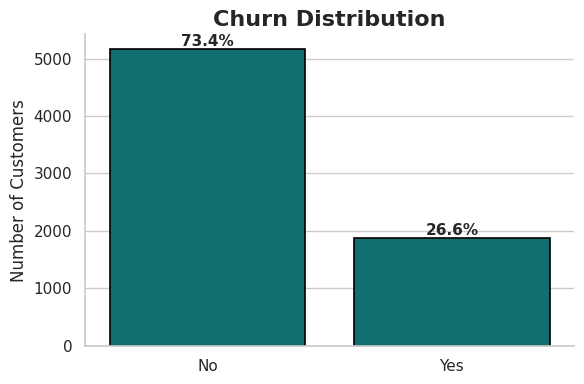

In [ ]:
# Display the proportion of each class in the 'Churn' column
df['Churn'].value_counts(normalize=True)

# Set the seaborn theme for consistent plot styling
sns.set_theme(style="whitegrid")

# Create a new figure with specified size
plt.figure(figsize=(6, 4))

# Generate a count plot showing the distribution of churn categories
ax = sns.countplot(
    data=df,
    x='Churn',
    color='teal',
    edgecolor='black',
    linewidth=1.2
)

# Calculate the total number of observations
total = len(df)

# Add percentage labels above each bar in the plot
for p in ax.patches:
    height = p.get_height()
    percentage = height / total
    ax.annotate(f'{percentage:.1%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

# Add title and axis labels to the plot
plt.title('Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Customers', fontsize=12)

# Remove top and right borders for a cleaner appearance
sns.despine()

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the final plot
plt.show()

### Key Insight from Target Variable Distribution

> The dataset is **imbalanced**, with approximately **73.4% of customers not churning** and **26.6% of customers churning**. This indicates that churn cases represent a smaller portion of the dataset.

**Note:** To address this imbalance during model development, several strategies can be applied. These include **class weighting**, **cost-sensitive learning**, and **resampling techniques** such as SMOTE (Synthetic Minority Over-sampling Technique) to help the model better learn patterns from the minority churn class.  

Additionally, **stratified sampling** can be used during the train-test split to preserve the original class distribution in both training and testing datasets. Evaluation metrics such as **recall** and **F1-score** will also be prioritised over accuracy to ensure the model effectively identifies customers who are likely to churn.

## **Categorical Feature Analysis**

To better understand how customer characteristics relate to churn behaviour, stacked percentage bar charts were generated for key **categorical variables** such as `gender`, `SeniorCitizen`, `Partner`, and `Dependents`.

These visualisations display the proportion of customers who **churned** and **did not churn** within each category, enabling clearer comparison of churn patterns across different customer groups.

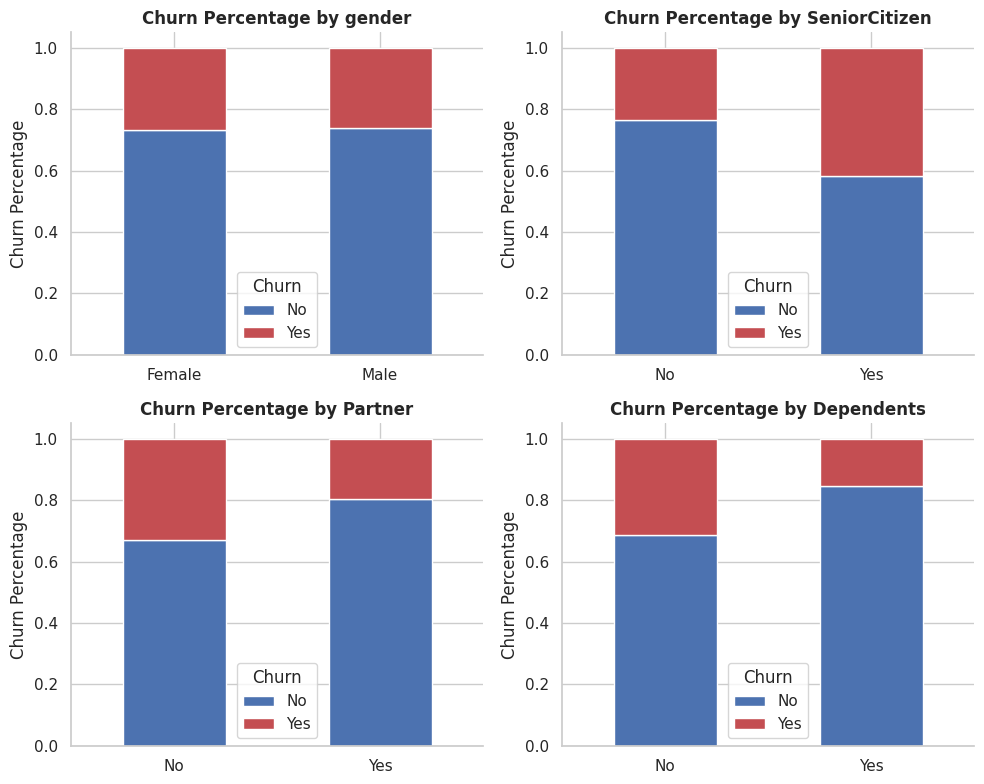

In [ ]:
# Set the seaborn theme for consistent plot styling
sns.set_theme(style="whitegrid")

# Create a copy of the dataframe to avoid modifying the original data
df_plot = df.copy()

# Convert SeniorCitizen values to categorical labels for clearer visualization
df_plot["SeniorCitizen"] = df_plot["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Define categorical features to analyze against churn
features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Loop through each feature to generate a stacked bar chart
for i, group in enumerate(features):

    # Select the current subplot axis
    ax = axes[i]

    # Calculate the proportion of churn within each category of the feature
    temp_df = (
        df_plot.groupby([group, "Churn"])
        .size()
        .div(df_plot.groupby(group).size(), axis=0)
        .unstack()
    )

    # Plot stacked bar chart showing churn distribution
    temp_df.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#4C72B0", "#C44E52"],
        edgecolor="white"
    )

    # Set subplot title and axis labels
    ax.set_title(f"Churn Percentage by {group}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Churn Percentage")
    ax.tick_params(axis="x", rotation=0)

    # Display legend indicating churn categories
    ax.legend(title="Churn")

    # Remove top and right plot borders for cleaner appearance
    sns.despine(ax=ax)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plots
plt.show()

### **Key Insights from Categorical Feature Analysis**

1. **Gender shows minimal impact on churn**  
   The churn rate is very similar across both groups (approximately **26-27%**), suggesting that `gender` is not a meaningful predictor of churn in this dataset.

2. **Senior citizens exhibit noticeably higher churn rates**  
   Customers classified as `SeniorCitizen` show a churn rate of around **42%**, compared to approximately **24%** for non-senior customers. This may indicate that this customer segment has different service needs or support expectations and could benefit from targeted retention strategies.

3. **Customers without partners churn more frequently**  
   Customers without a partner exhibit a higher churn rate (around **33%**) compared to those with partners (around **20%**), suggesting that household stability may be associated with longer customer relationships.

4. **Customers without dependents are more likely to churn**  
   The churn rate for customers without dependents is approximately **31%**, while customers with dependents show a significantly lower churn rate of about **16%**, which may reflect greater service reliance among households with dependents.

> **Overall Insight:** Household and demographic characteristics such as `SeniorCitizen`, `Partner`, and `Dependents` appear to be associated with churn behaviour, whereas `gender` does not demonstrate a meaningful influence.

## **Service and Subscription Feature Analysis**

To examine how different **service and subscription-related features** are associated with customer churn, stacked percentage bar charts were generated. These visualisations display the proportion of customers who churned and did not churn within each service category, enabling comparison of churn patterns across different service usage and billing characteristics.

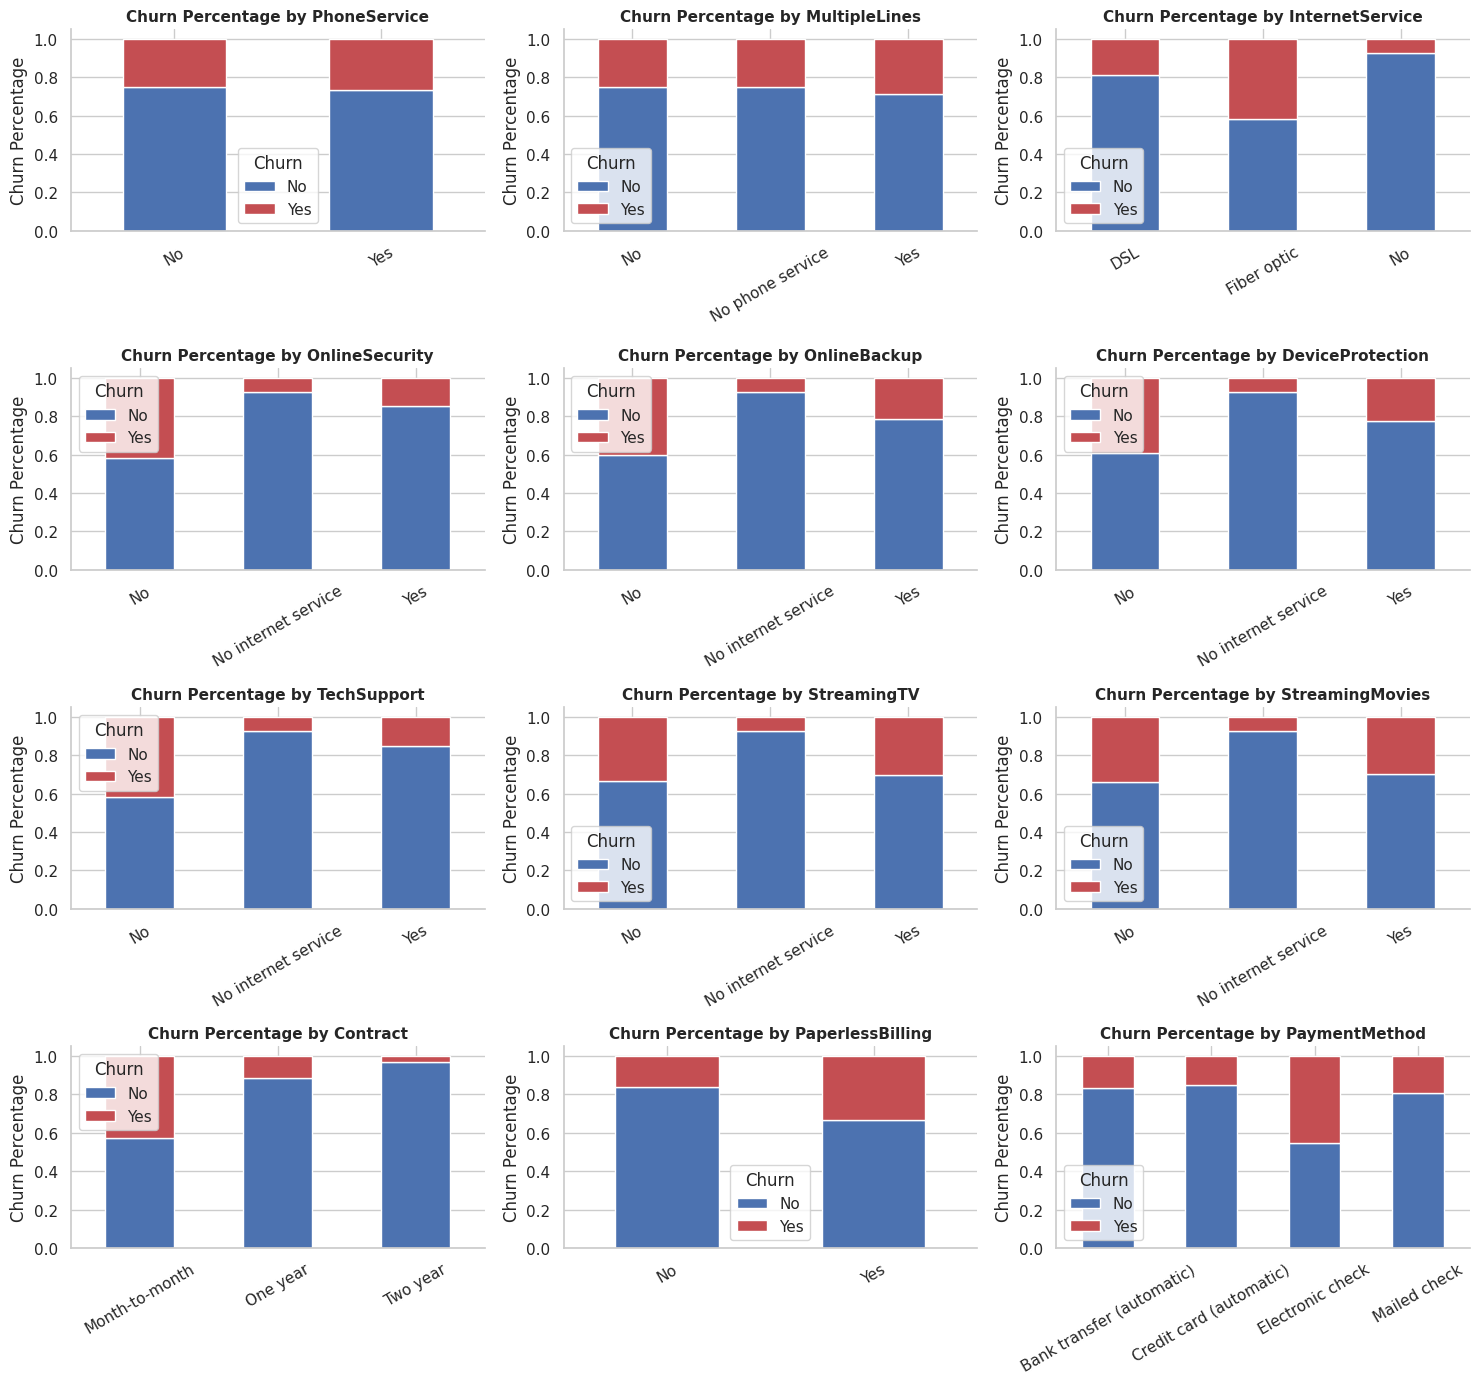

In [ ]:
# Set the seaborn theme for consistent plot styling
sns.set_theme(style="whitegrid")

# Create a copy of the dataframe to preserve the original data
df_plot = df.copy()

# Define service and contract related features to analyze against churn
features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Create a grid of subplots for visualizing multiple features
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

# Loop through each feature to generate stacked bar charts
for i, group in enumerate(features):

    # Select the current subplot axis
    ax = axes[i]

    # Calculate the churn proportion within each category of the feature
    temp_df = (
        df_plot.groupby([group, "Churn"])
        .size()
        .div(df_plot.groupby(group).size(), axis=0)
        .unstack()
    )

    # Plot stacked bar chart showing churn distribution
    temp_df.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#4C72B0", "#C44E52"],
        edgecolor="white"
    )

    # Set subplot title and axis labels
    ax.set_title(f"Churn Percentage by {group}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Churn Percentage")
    ax.tick_params(axis="x", rotation=30)

    # Display legend indicating churn categories
    ax.legend(title="Churn")

    # Remove top and right plot borders for cleaner appearance
    sns.despine(ax=ax)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plots
plt.show()

### **Key Insights from Service and Subscription Feature Analysis**

1. **Contract type shows the strongest churn pattern**  
   Customers on `Month-to-month` contracts exhibit the highest churn rates, while `One year` and particularly `Two year` contracts show substantially lower churn.  
   ***Possible reason:*** Longer contracts create stronger commitment and switching costs, reducing the likelihood of customers leaving.

2. **Internet service type is strongly associated with churn**  
   Customers using `Fiber optic` internet display higher churn compared to `DSL` users, while customers with `No internet service` show the lowest churn levels.  
   ***Possible reason:*** Fiber customers may have higher expectations due to premium pricing, making them more sensitive to service quality or pricing dissatisfaction.

3. **Security and technical support services reduce churn**  
   Customers with `OnlineSecurity` and `TechSupport` services tend to churn less, whereas those without these services show noticeably higher churn rates.  
   ***Possible reason:*** These services increase perceived value and provide assistance when issues arise, strengthening customer reliance on the provider.

4. **Backup and device protection follow a similar pattern**  
   Customers with `OnlineBackup` and `DeviceProtection` generally exhibit lower churn compared to those who do not use these services.  
   ***Possible reason:*** Customers using more integrated services may be more embedded in the ecosystem, increasing switching costs.

5. **Paperless billing is linked to higher churn**  
   Customers using `PaperlessBilling` demonstrate a higher churn proportion than those who do not.  
   ***Possible reason:*** Paperless billing is more common among digitally engaged customers who may also find it easier to compare alternatives and switch providers.

6. **Payment method shows a clear behavioural pattern**  
   Customers paying via `Electronic check` exhibit the highest churn, while **automatic payment methods** such as `Bank transfer` or `Credit card` are associated with lower churn.  
   ***Possible reason:*** Automatic payments create friction against cancellation, while manual payment methods may reflect lower commitment.

7. **Phone service and multiple lines have weaker influence**  
   Churn proportions remain relatively similar across `PhoneService` and `MultipleLines`, suggesting these variables are less influential predictors.  
   ***Possible reason:*** These services may be considered basic utilities and do not significantly affect overall customer satisfaction.

8. **Streaming services show only moderate differences**  
   `StreamingTV` and `StreamingMovies` display smaller churn differences compared with factors such as contract type, internet service, and support/security services.  
   ***Possible reason:*** These features may act as complementary add-ons rather than core drivers of retention.

> **Overall Insight:** Churn appears most strongly associated with **contract commitment**, **internet service type**, and **support/security services**, while **billing and payment behaviour** also shows meaningful behavioural patterns influencing retention.

## **Numerical Feature Analysis**

To explore how **numerical features** relate to customer churn, kernel density estimation (KDE) plots were generated for `tenure`, `MonthlyCharges`, and `TotalCharges`.  

These visualisations compare the distribution of each variable between customers who churned and those who did not churn, helping to identify differences in customer behaviour across the two groups.

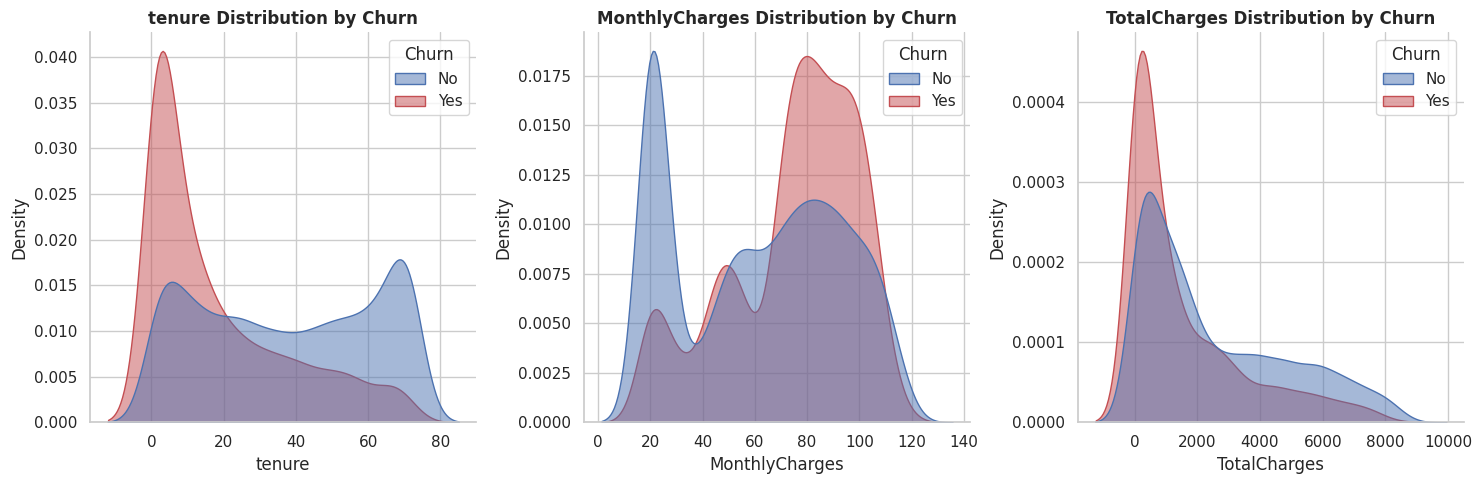

In [ ]:
# Set the seaborn theme for consistent plot styling
sns.set_theme(style="whitegrid")

# Define numerical columns to analyze
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create subplots for each numerical variable
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 5))

# Loop through numerical columns to plot density distributions
for i, col in enumerate(num_cols):

    # Plot KDE distribution of the variable separated by churn status
    sns.kdeplot(
        data=df,
        x=col,
        hue="Churn",
        fill=True,
        common_norm=False,
        palette=["#4C72B0", "#C44E52"],
        alpha=0.5,
        ax=axes[i]
    )

    # Set title and axis labels for each subplot
    axes[i].set_title(f"{col} Distribution by Churn", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

# Remove top and right borders for a cleaner appearance
sns.despine()

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plots
plt.show()

### **Key Insights from Numerical Feature Analysis**

1. **Tenure strongly differentiates churn behaviour**  
   Customers who churn tend to have **significantly shorter tenure**, while customers with longer tenure are much more likely to remain with the service.  
   ***Possible explanation:*** Customers are often most likely to leave during the **early stages of the customer lifecycle**, before strong service dependency or switching costs develop.

2. **Higher monthly charges are associated with churn**  
   Churned customers are more concentrated in **higher monthly charge ranges**, suggesting that higher pricing may contribute to customer attrition.  
   ***Possible explanation:*** Higher costs may increase **price sensitivity**, particularly if customers perceive limited value relative to the price paid.

3. **Total charges reflect tenure-driven churn patterns**  
   Customers who churn generally have **lower total charges**, which aligns with their shorter tenure, while long-standing customers accumulate much higher total charges.  
   ***Possible explanation:*** Customers who remain longer naturally accumulate higher total charges, indicating that **retained customers contribute greater lifetime value**.

> **Overall Insight:** Customers who churn tend to be **newer customers paying relatively higher monthly charges**, whereas **long-tenure customers with accumulated total charges are far less likely to churn**, highlighting the importance of **early-stage retention strategies**.

# **Overall Key Insights from Exploratory Data Analysis**

1. **Customer commitment is the strongest indicator of churn**  
   Customers on `Month-to-month` contracts and those with **short tenure** show significantly higher churn rates. In contrast, customers with longer tenure or longer-term contracts are far more likely to remain with the service.

2. **Service value and support features reduce churn risk**  
   Customers who subscribe to services such as `OnlineSecurity`, `TechSupport`, `OnlineBackup`, and `DeviceProtection` exhibit noticeably lower churn, suggesting that value-added services contribute to stronger customer retention.

3. **Pricing and billing behaviour are linked to churn**  
   Customers with **higher monthly charges** and those using `Electronic check` payments or `PaperlessBilling` tend to churn more frequently, indicating potential price sensitivity or billing-related friction.

4. **Internet service type plays an important role**  
   Customers using `Fiber optic` internet show higher churn proportions compared to `DSL` users, while customers with `No internet service` exhibit the lowest churn levels.

5. **Household characteristics influence churn behaviour**  
   Customers who are `SeniorCitizen`, single (`Partner = No`), or without `Dependents` display higher churn rates, while `gender` does not appear to meaningfully influence churn.

> **Overall Takeaway:** Customer churn is most strongly associated with **contract flexibility, tenure, pricing, and service support features**. Strengthening customer commitment and promoting value-added services may therefore be effective strategies for reducing customer attrition.

## **Numerical Feature Distribution and Preprocessing Considerations**

To examine the distribution of numerical features, histograms with **kernel density estimates (KDE)** were generated for `tenure`, `MonthlyCharges`, and `TotalCharges`. Mean and median reference lines were also included to highlight the **central tendency** of each variable and to help identify potential **skewness** in the distributions.

In [ ]:
# Function to plot histogram with mean and median lines for a given column
def plot_histogram(df, column_name):

  plt.figure(figsize=(8, 5))
  sns.histplot(df[column_name], kde=True, color="#5E3C99")
  plt.title(f"Distribution of {column_name}")

  # Calculate mean and median
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # Add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()
  plt.show()

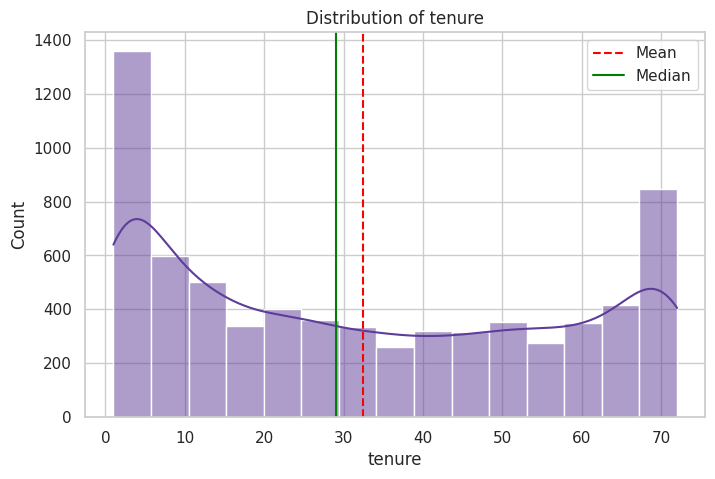

In [ ]:
plot_histogram(df, "tenure")

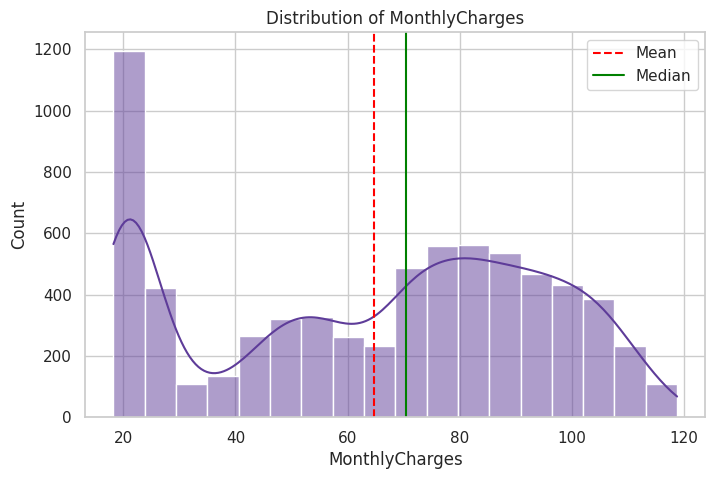

In [ ]:
plot_histogram(df, "MonthlyCharges")

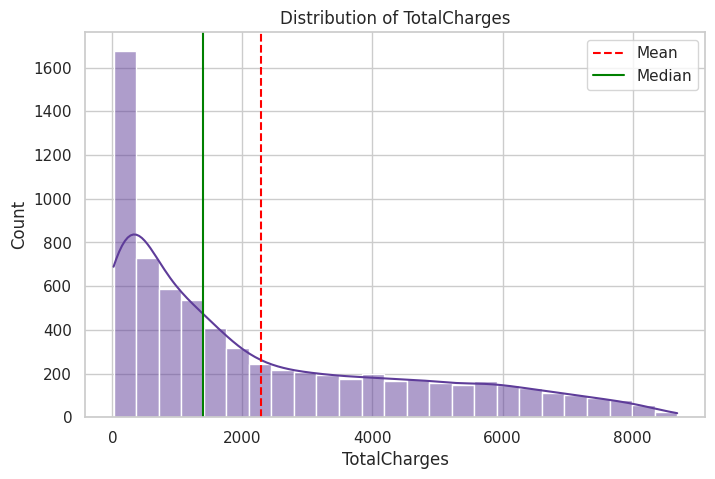

In [ ]:
plot_histogram(df, "TotalCharges")

### **Key Insights from Numerical Feature Distribution**

1. **Monthly charges show moderate variability**  
   The distribution of `MonthlyCharges` spans a wide range, with a concentration around mid-to-higher values. The mean and median are relatively close, indicating a fairly balanced distribution with only slight skewness.

2. **Tenure reflects both new and long-term customers**  
   A noticeable portion of customers have very short `tenure`, while another large group has tenure close to the maximum range. The mean being slightly higher than the median suggests mild right skew, reflecting the presence of long-standing customers.

3. **Total charges are strongly right-skewed**  
   Most customers have relatively low `TotalCharges`, while a smaller group accumulates much higher values. The mean being significantly higher than the median confirms a strongly right-skewed distribution.

4. **Tenure and total charges are naturally related**  
   Since `TotalCharges` accumulate over time, customers with longer tenure tend to contribute to the higher range of total charges, explaining the long tail observed in the distribution.

> **Overall Insight:** The numerical features show varying levels of skewness, particularly for `TotalCharges`, while `tenure` highlights the presence of both newly acquired and long-standing customers within the dataset, suggesting a bimodal distribution.

## **Preprocessing**

### Binary Encoding of Categorical Variables

To prepare the data for machine learning models, binary categorical variables were converted into numerical format using a predefined mapping (e.g., `Yes = 1`, `No = 0`, `Male = 1`, `Female = 0`).  
Service-related categories such as `No internet service` and `No phone service` were also mapped to `0`, as they indicate the absence of the respective service.

> NOTE: This transformation is **rule-based and does not rely on dataset statistics**, meaning it does not introduce **data leakage**. The encoding simply standardises categorical responses into numerical values required by many machine learning algorithms.

In [ ]:
# Map binary categorical values to 0 and 1
binary_map = {'Yes':1, 'No':0, 'Female':0, 'Male':1}

for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [ ]:
# Map service-related categorical values to 0 and 1
service_map = {'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0}

for col in service_cols:
    df[col] = df[col].map(service_map)

In [ ]:
# Check for any missing values in mapped binary and service columns
print("NaNs after mapping:", df[binary_cols + service_cols].isnull().sum())

NaNs after mapping: gender              0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
Churn               0
MultipleLines       0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


In [ ]:
# Drop 'customerID' column as it is not needed for analysis (not useful)
df = df.drop("customerID", axis=1)

## **Data Cleaning Summary**

The dataset is now prepared for further analysis and modeling:

- All **column data types** have been corrected.  
- **Missing values** have been identified and handled appropriately.

# **Feature Engineering**

### Derived Features

Two additional features were created to capture customer spending behaviour and early-stage customer risk:

- **Average Monthly Spend (`AvgMonthlySpend`)** was calculated by dividing `TotalCharges` by `tenure`. To avoid division by zero for customers with zero tenure, values of `0` in `tenure` were temporarily replaced with `1` during the calculation.

- **Short Tenure (`ShortTenure`)** was introduced as a binary indicator identifying customers with less than **6 months of tenure**. Customers meeting this condition are assigned a value of `1`, while others are assigned `0`.

These derived features help capture **customer spending patterns** and **early lifecycle behaviour**, which may provide additional predictive value for churn modeling.

In [ ]:
# Create 'AvgMonthlySpend' column, avoiding division by zero by replacing tenure 0 with 1
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'].replace(0, 1))

# Create binary feature for customers with short tenure (<6 months)
df['ShortTenure'] = (df['tenure'] < 6).astype(int)

## **Correlation and Multicollinearity Check**

- Linear models, such as **Logistic Regression**, can be affected by highly correlated features (**multicollinearity**), which may lead to unstable coefficient estimates and reduced interpretability.

- Tree-based models such as **Random Forest** and **XGBoost** are generally less sensitive to multicollinearity, as they rely on feature splits rather than coefficient estimation.

- Although multicollinearity is less problematic for tree-based algorithms, examining feature correlations remains **good analytical practice** to better understand relationships within the dataset.

> At this stage, correlated variables are **not removed immediately**. Instead, feature importance and selection will be evaluated during the **modeling and hyperparameter tuning stage**, where the **most informative features** will be identified and retained.

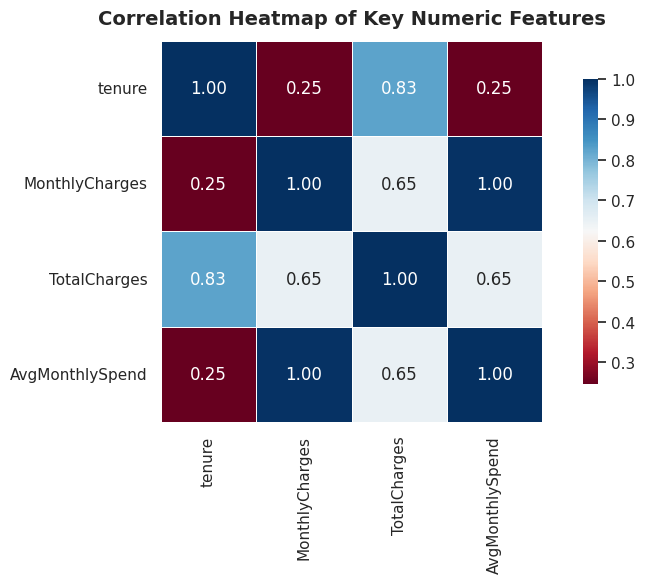

In [ ]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(9,6))

# Compute correlation matrix
corr = df[['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend']].corr()

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": .8}
)

# Title formatting
plt.title("Correlation Heatmap of Key Numeric Features", fontsize=14, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

## **Outlier Detection (Numerical Features)**

- Outliers in numerical features can influence certain models, particularly **Logistic Regression**, and may distort results when **feature scaling** is applied.

- To identify potential anomalies, the **Interquartile Range (IQR) method** is used. This approach detects values that fall significantly outside the typical range of the data distribution.

- Observations identified through the IQR method will be **examined and removed (if any)** where appropriate to reduce their potential impact on model training and improve the robustness of the analysis.

> **Note:** Values flagged as "outliers" by statistical methods are not always true anomalies. In real-world applications, these observations may represent valid but rare cases. In more rigorous analytical or operational settings, such cases should be **validated with domain knowledge and clearly communicated to stakeholders** before removal to avoid discarding meaningful information.

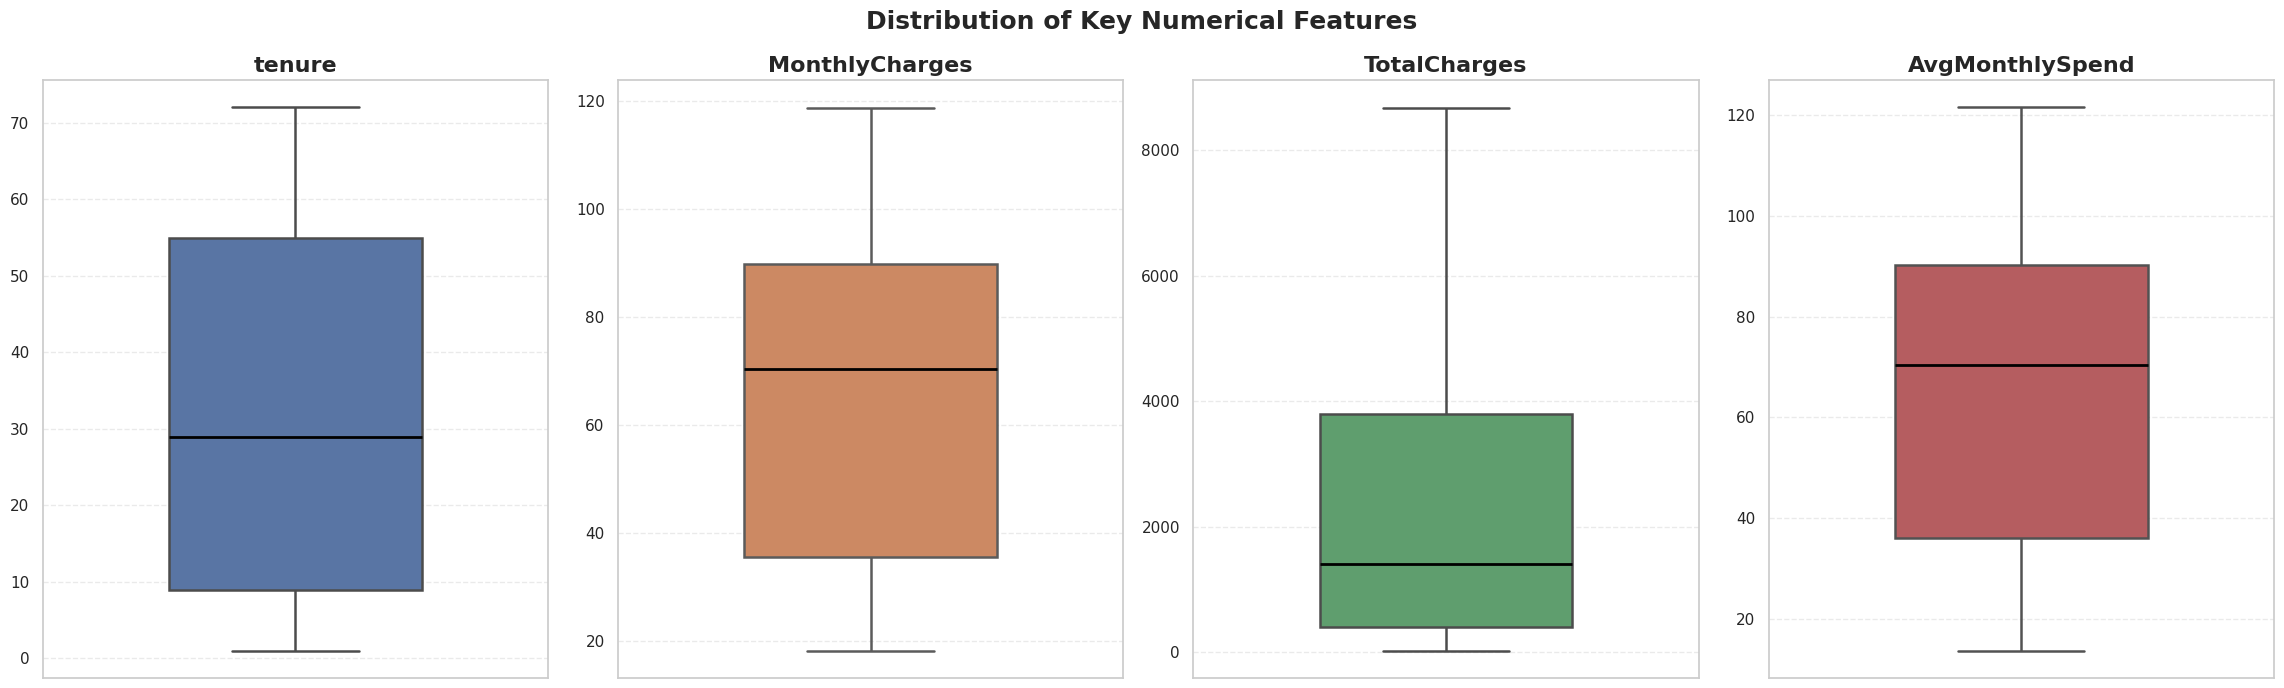

In [ ]:
# Define numerical columns to visualize
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

# Set seaborn theme and context for clean plot styling
sns.set_theme(style="whitegrid", context="notebook")

# Generate a color palette for the boxplots
palette = sns.color_palette("deep", len(num_cols))

# Create subplots for each numerical feature
fig, axes = plt.subplots(1, len(num_cols), figsize=(23, 7))

# Loop through each numerical column to create a boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color=palette[i],
        width=0.5,
        linewidth=1.8,
        fliersize=4,
        medianprops=dict(color="black", linewidth=2)
    )

    # Set subplot title and adjust axis labels
    axes[i].set_title(col, fontsize=16, fontweight='bold')
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='y', labelsize=11)

    # Add light gridlines along the y-axis
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.4)

# Add main title for the figure
fig.suptitle("Distribution of Key Numerical Features", fontsize=18, fontweight="bold")

# Adjust layout to avoid overlapping elements
plt.tight_layout()

# Display the plots
plt.show()

In [ ]:
# Identify outliers in numerical columns using the IQR method
for col in num_cols:

    # Calculate the first and third quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Compute the interquartile range
    IQR = Q3 - Q1

    # Define lower and upper bounds for outlier detection
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    # Select rows where values fall outside the defined bounds
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # Print the number of detected outliers for the column
    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers
AvgMonthlySpend: 0 outliers


### Outlier Detection Results

Visual inspection using **boxplots**, together with the **IQR-based analysis**, indicates that the numerical features do not contain significant outliers. The distributions appear consistent, with no extreme values falling beyond the expected ranges.

As a result, no observations were removed, and the numerical features are considered **clean and suitable for modeling**.

# **Model Development**

This stage focuses on developing and comparing multiple supervised classification models to predict customer churn. The dataset was split into training and test sets using a **stratified** strategy to preserve the original churn distribution, ensuring that evaluation is representative despite class imbalance.

To support robust and reproducible experimentation, all preprocessing and modeling steps were implemented using **scikit-learn Pipelines**. Numerical variables were scaled and categorical variables were one-hot encoded within a unified preprocessing workflow, ensuring consistent transformations across models and preventing accidental inconsistencies between training and test data.

Feature selection was incorporated for selected models using embedded methods (`SelectFromModel`), helping reduce noise and improve generalisation by retaining the most informative predictors. Model performance was assessed using classification metrics with a strong emphasis on **recall**, reflecting the importance of correctly identifying customers at risk of churn.

Hyperparameter tuning was conducted using **GridSearchCV** (for Logistic Regression, Decision Tree, and Random Forest) and **RandomizedSearchCV** (for XGBoost), with cross-validation and recall-based scoring to prioritise churn detection. Class imbalance was addressed through **class weighting** and, for XGBoost, an imbalance-aware scaling parameter. (***NOTE: SMOTE could also be applied; however, the class imbalance was moderate rather than severe, making class weighting a more appropriate choice for this dataset as it preserves the original data distribution while still penalising misclassification of the minority class***)

## **Data Leakage Considerations**

> Potential data leakage was carefully managed by ensuring that any transformations informed by the data (e.g., scaling and encoding) were learned only from the training set via pipelines and then applied to the test set. In addition, the engineered feature based on the median of `MonthlyCharges` was derived using the **training data only** and then applied consistently to the test set. This preserves the integrity of the evaluation and prevents information from the test set influencing model training.

### **Train-Test Split**

The dataset was divided into **features (`X`)** and the **target variable (`Churn`)**, and then split into **training (80%)** and **testing (20%)** sets.  

A **stratified split** was applied to preserve the original class distribution of churn and non-churn customers, ensuring a fair and reliable evaluation of model performance.

In [ ]:
# Separate features and target variable
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=41
)

### **Derived Feature: High Monthly Charges**

A binary feature, `HighMonthlyCharges`, was created to indicate whether a customer's `MonthlyCharges` exceed the **median value observed in the training data**.

The median was calculated using only the **training set** and then applied to both training and test data. This approach ensures **consistency while preventing data leakage** during model evaluation.

In [ ]:
# Compute the median MonthlyCharges using the training data
median_charge = X_train["MonthlyCharges"].median()

# Create a binary feature indicating whether MonthlyCharges is above the median
X_train["HighMonthlyCharges"] = (X_train["MonthlyCharges"] > median_charge).astype(int)

# Apply the same threshold to create the feature in the test data
X_test["HighMonthlyCharges"] = (X_test["MonthlyCharges"] > median_charge).astype(int)

### **Feature Grouping**

The predictor variables were separated into **numerical** and **categorical** feature groups. This allows appropriate preprocessing, such as **scaling numerical features** and **encoding categorical variables**, to be applied within the modeling pipeline.

In [ ]:
# Define numerical feature columns used for modeling
num_cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AvgMonthlySpend',
    'ShortTenure',
    'HighMonthlyCharges',
]

# Define categorical feature columns used for modeling
cat_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

## **Preprocessing, Pipelines, and Model Tuning**

> Preprocessing was applied using a `ColumnTransformer`, with numerical features scaled and categorical features one-hot encoded within a single workflow. This preprocessing was embedded inside **model pipelines**, ensuring consistent transformations and reducing the risk of **data leakage**.

> Multiple models were trained and compared using both baseline and tuned versions, including **Logistic Regression**, **Decision Tree**, **Random Forest**, and **XGBoost**. Feature selection was applied within selected pipelines to retain the most informative predictors.

> **Hyperparameter tuning** was performed using cross-validation with **recall** as the primary scoring metric to prioritise identifying churn cases. Class imbalance was handled using **class weighting** and **imbalance-aware parameters** where appropriate.

### **Preprocessing Pipeline for Feature Scaling, Encoding, and Model Evaluation**

In [ ]:
# Create a preprocessing step for numeric scaling and categorical encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_cols),  # Standardize numeric features
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # One-hot encode categorical features
    ]
)

# Define a helper function to print evaluation metrics for a trained model
def eval_model(name, model, X_test, y_test):
    # Generate predictions on the test set
    y_pred = model.predict(X_test)
    # Print model name and evaluation outputs
    print("\n", name)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

### **Logistic Regression Pipeline: Feature Selection, Training, and Hyperparameter Optimization**

In [ ]:
# Build a Logistic Regression pipeline with preprocessing and embedded feature selection
lr_pipe = Pipeline([
    ("preprocessing", preprocessor),  # Apply scaling and encoding
    ("select", SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),
        threshold="median"  # Select features above the threshold
    )),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))  # Final classifier
])

# Fit the baseline Logistic Regression pipeline
lr_pipe.fit(X_train, y_train)
# Evaluate baseline Logistic Regression performance
eval_model("LR BASELINE", lr_pipe, X_test, y_test)


# Configure grid search to tune Logistic Regression hyperparameters
lr_grid = GridSearchCV(
    lr_pipe,
    param_grid={
        "select__threshold": ["median", "mean", 0.01, 0.02],  # Feature selection threshold options
        "model__C": [0.1, 1, 10],  # Regularization strength options
        "model__solver": ["liblinear", "lbfgs"],  # Solver options
        "model__class_weight": [None, "balanced"]  # Class weighting options
    },
    cv=3,  # Cross-validation folds
    scoring="recall",  # Optimize for recall
    n_jobs=-1  # Use all available cores
)

# Fit the grid search on training data
lr_grid.fit(X_train, y_train)
# Evaluate tuned Logistic Regression performance
eval_model("LR TUNED", lr_grid, X_test, y_test)
# Print best cross-validation score and parameters
print("LR BEST", lr_grid.best_score_, lr_grid.best_params_)


 LR BASELINE
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1033
           1       0.54      0.82      0.65       374

    accuracy                           0.77      1407
   macro avg       0.73      0.79      0.74      1407
weighted avg       0.82      0.77      0.78      1407

[[774 259]
 [ 66 308]]

 LR TUNED
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1033
           1       0.55      0.82      0.66       374

    accuracy                           0.77      1407
   macro avg       0.73      0.79      0.74      1407
weighted avg       0.82      0.77      0.78      1407

[[779 254]
 [ 67 307]]
LR BEST 0.7986320700302881 {'model__C': 10, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs', 'select__threshold': 0.02}


### **Decision Tree Pipeline: Feature Selection, Training, and Hyperparameter Optimization**

In [ ]:
# Build a Decision Tree pipeline with preprocessing and feature selection
dt_pipe = Pipeline([
    ("preprocessing", preprocessor),  # Apply preprocessing; scaling unnecessary for DT and could be removed, kept for pipeline consistency
    ("select", SelectFromModel(
        DecisionTreeClassifier(random_state=42, class_weight="balanced"),
        threshold="median"  # Select features above the threshold
    )),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))  # Final classifier
])

# Fit the baseline Decision Tree pipeline
dt_pipe.fit(X_train, y_train)
# Evaluate baseline Decision Tree performance
eval_model("DT BASELINE", dt_pipe, X_test, y_test)


# Configure grid search to tune Decision Tree hyperparameters
dt_grid = GridSearchCV(
    dt_pipe,
    param_grid={
        "select__threshold": ["median", "mean"],  # Feature selection threshold options
        "model__max_depth": [None, 5, 10],  # Maximum tree depth options
        "model__min_samples_split": [2, 10],  # Minimum samples required to split a node
        "model__min_samples_leaf": [1, 4]  # Minimum samples required in a leaf
    },
    cv=3,  # Cross-validation folds
    scoring="recall",  # Optimize for recall
    n_jobs=-1  # Use all available cores
)

# Fit the grid search on training data
dt_grid.fit(X_train, y_train)
# Evaluate tuned Decision Tree performance
eval_model("DT TUNED", dt_grid, X_test, y_test)
# Print best cross-validation score and parameters
print("DT BEST", dt_grid.best_score_, dt_grid.best_params_)


 DT BASELINE
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.49      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407

[[846 187]
 [189 185]]

 DT TUNED
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.77      1407

[[758 275]
 [ 73 301]]
DT BEST 0.7946455159314613 {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'select__threshold': 'mean'}


### **Random Forest Pipeline: Feature Selection, Training, and Hyperparameter Optimization**

In [ ]:
# Build a Random Forest pipeline with preprocessing and feature selection
rf_pipe = Pipeline([
    ("preprocessing", preprocessor),  # Apply preprocessing; scaling unnecessary for RF and could be removed, kept for pipeline consistency
    ("select", SelectFromModel(
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_estimators=300,
            n_jobs=-1
        ),
        threshold="median"  # Select features above the threshold
    )),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1))  # Final classifier
])

# Fit the baseline Random Forest pipeline
rf_pipe.fit(X_train, y_train)
# Evaluate baseline Random Forest performance
eval_model("RF BASELINE", rf_pipe, X_test, y_test)


# Configure grid search to tune Random Forest hyperparameters
rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={
        "select__threshold": ["median", "mean"],  # Feature selection threshold options
        "model__n_estimators": [200, 300],  # Number of trees options
        "model__max_depth": [None, 10],  # Maximum tree depth options
        "model__min_samples_split": [2, 10],  # Minimum samples required to split a node
        "model__min_samples_leaf": [1, 4],  # Minimum samples required in a leaf
        "model__max_features": ["sqrt"]  # Feature sampling strategy
    },
    cv=3,  # Cross-validation folds
    scoring="recall",  # Optimize for recall
    n_jobs=-1  # Use all available cores
)

# Fit the grid search on training data
rf_grid.fit(X_train, y_train)
# Evaluate tuned Random Forest performance
eval_model("RF TUNED", rf_grid, X_test, y_test)
# Print best cross-validation score and parameters
print("RF BEST", rf_grid.best_score_, rf_grid.best_params_)


 RF BASELINE
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

[[933 100]
 [180 194]]

 RF TUNED
              precision    recall  f1-score   support

           0       0.91      0.79      0.84      1033
           1       0.57      0.78      0.66       374

    accuracy                           0.78      1407
   macro avg       0.74      0.78      0.75      1407
weighted avg       0.82      0.78      0.79      1407

[[811 222]
 [ 82 292]]
RF BEST 0.7217031117120452 {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300, 'select__threshold': 'mean'}


### **XGBoost Pipeline: Training and Hyperparameter Optimization**

In [ ]:
# Build an XGBoost pipeline with preprocessing and a boosted tree classifier
xgb_pipe = Pipeline([
    ("preprocessing", preprocessor),  # Shared preprocessing; scaling unnecessary for tree-based models (DT, RF, XGBoost) and could be removed
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# Fit the baseline XGBoost pipeline
xgb_pipe.fit(X_train, y_train)
# Evaluate baseline XGBoost performance
eval_model("XGB BASELINE", xgb_pipe, X_test, y_test)

# Compute the class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = (neg / pos) if pos else 1.0

# Configure randomized search to tune XGBoost hyperparameters
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions={
        "model__n_estimators": [200, 300, 400, 600],  # Boosting rounds options
        "model__max_depth": [3, 4, 5, 6],  # Tree depth options
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],  # Learning rate options
        "model__subsample": [0.7, 0.8, 0.9, 1.0],  # Row sampling options
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],  # Feature sampling options
        "model__min_child_weight": [1, 3, 5, 7],  # Minimum child weight options
        "model__gamma": [0, 0.25, 0.5, 1.0],  # Minimum loss reduction options
        "model__reg_lambda": [1, 2, 5, 10],  # L2 regularization options
        "model__reg_alpha": [0, 0.1, 0.5, 1.0],  # L1 regularization options
        "model__scale_pos_weight": [spw, spw * 0.75, spw * 1.25]  # Class imbalance weight options
    },
    n_iter=60,  # Number of parameter settings sampled
    cv=5,  # Cross-validation folds
    scoring="recall",  # Optimize for recall
    n_jobs=-1,  # Use all available cores
    random_state=42  # Reproducibility
)

# Fit the randomized search on training data
xgb_search.fit(X_train, y_train)
# Evaluate tuned XGBoost performance
eval_model("XGB TUNED", xgb_search, X_test, y_test)
# Print best cross-validation score and parameters
print("XGB BEST", xgb_search.best_score_, xgb_search.best_params_)


 XGB BASELINE
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1033
           1       0.68      0.54      0.60       374

    accuracy                           0.81      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407

[[938  95]
 [171 203]]

 XGB TUNED
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1033
           1       0.49      0.87      0.63       374

    accuracy                           0.73      1407
   macro avg       0.71      0.77      0.71      1407
weighted avg       0.82      0.73      0.74      1407

[[696 337]
 [ 49 325]]
XGB BEST 0.8561872909698997 {'model__subsample': 0.8, 'model__scale_pos_weight': np.float64(3.4531772575250836), 'model__reg_lambda': 5, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__min_child_weight': 7, 'model__max_depth': 3, 'model__learning_rate': 0.01, 

# **Model Evaluation and Comparison**

Model performance was summarised using key classification metrics, including **accuracy**, **precision**, **recall**, and **F1-score**, to enable a clear comparison between baseline and tuned models.

A consolidated results table was produced to highlight overall performance across models, with particular focus on **recall** due to the importance of correctly identifying churn cases.

Finally, a **confusion matrix** was visualised for the best-performing tuned model to show the distribution of true positives, true negatives, false positives, and false negatives, providing deeper insight into the model's classification behaviour.

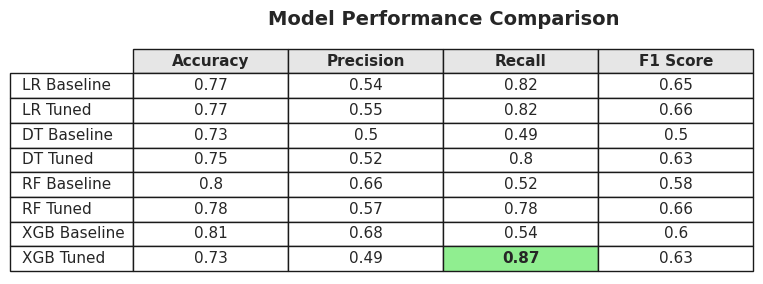

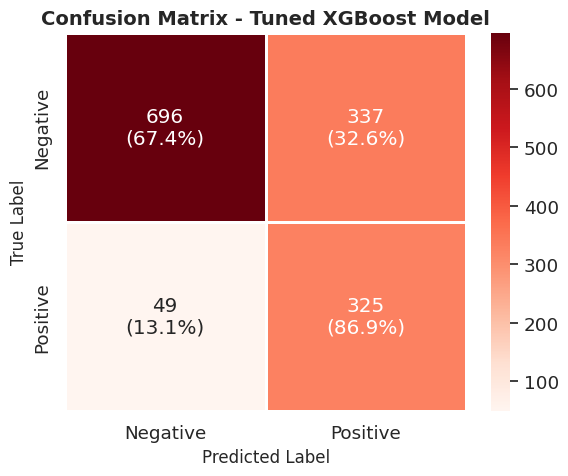

In [ ]:
# Define a function to compute key classification metrics
def get_metrics(model, X_test, y_test):
    # Generate predictions on the test set
    y_pred = model.predict(X_test)

    # Return metrics as a dictionary for easy tabulation
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }


# Store evaluation results for baseline and tuned models
results = {
    "LR Baseline": get_metrics(lr_pipe, X_test, y_test),
    "LR Tuned": get_metrics(lr_grid.best_estimator_, X_test, y_test),

    "DT Baseline": get_metrics(dt_pipe, X_test, y_test),
    "DT Tuned": get_metrics(dt_grid.best_estimator_, X_test, y_test),

    "RF Baseline": get_metrics(rf_pipe, X_test, y_test),
    "RF Tuned": get_metrics(rf_grid.best_estimator_, X_test, y_test),

    "XGB Baseline": get_metrics(xgb_pipe, X_test, y_test),
    "XGB Tuned": get_metrics(xgb_search.best_estimator_, X_test, y_test)
}

# Convert the results dictionary into a dataframe for display
results_df = pd.DataFrame(results).T

# Round metric values for cleaner presentation
results_df = results_df.round(2)

# Create a figure and remove axes for a table-only display
fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')

# Render the dataframe as a matplotlib table
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    rowLabels=results_df.index,
    loc='center',
    cellLoc='center'
)

# Set table font size and scaling for readability
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.5)

# Apply styling to the header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#E6E6E6")

# Highlight the tuned XGBoost recall cell
table[(8,2)].set_facecolor("#90EE90")
table[(8,2)].set_text_props(weight='bold')

# Add a title above the table
plt.title("Model Performance Comparison", fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# Retrieve the best-performing model found during RandomizedSearchCV
best_model = xgb_search.best_estimator_

# Generate predictions for the test dataset using the optimized model
y_pred = best_model.predict(X_test)

# Compute the confusion matrix comparing true labels and predicted labels
cm = confusion_matrix(y_test, y_pred)

# Define class labels for the confusion matrix axes
labels = ["Negative", "Positive"]

# Compute row-wise percentages for interpretability
cm_percent = cm / cm.sum(axis=1)[:, np.newaxis]

# Build annotations combining counts and percentages
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"

# Create a figure for the confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.set(style="white", font_scale=1.2)

# Plot the confusion matrix as a heatmap with annotations
ax = sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Reds",
    linewidths=1,
    linecolor="white",
    cbar=True,
    xticklabels=labels,
    yticklabels=labels
)

# Set axis labels and title
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Tuned XGBoost Model", fontsize=14, weight="bold")

# Adjust layout and display the heatmap
plt.tight_layout()
plt.show()

## **Key Results and Model Comparison**

The performance comparison shows clear differences across the evaluated models. While several models achieved strong accuracy, **recall** was prioritised because the primary objective is to correctly identify customers who are likely to churn.

- The **tuned XGBoost model** achieved the highest recall (**0.87**), indicating that it successfully identifies the majority of churn cases. Although this model shows slightly lower accuracy and precision compared to some alternatives, its ability to detect churn makes it the most suitable model for this problem.

- Logistic Regression demonstrated stable performance with strong recall (**0.82**) and balanced metrics overall, making it a competitive and interpretable alternative. Random Forest also performed well after tuning, improving recall to **0.78**.

- Decision Tree models showed the greatest improvement after tuning, increasing recall from **0.49** to **0.80**, though their overall performance remained slightly lower than the best-performing models.

> Overall, the results indicate that **ensemble and boosting-based methods**, particularly **XGBoost**, provide the most effective performance for detecting churn in this dataset.

### **Confusion Matrix Interpretation (Tuned XGBoost)**

The confusion matrix for the tuned XGBoost model provides additional insight into how the model performs when identifying churners.

- **True Negatives (696):**  
  The model correctly identifies the majority of non-churning customers, indicating that it maintains reasonable performance in recognising customers who are likely to stay.

- **True Positives (325):**  
  The model successfully detects a large proportion of customers who actually churn. This strong detection rate aligns with the model's high recall (**0.87**), ensuring that most churn cases are captured.

- **False Positives (337):**  
  Some customers predicted to churn do not actually churn. While this increases the number of unnecessary retention interventions, this trade-off is acceptable in churn prediction, where missing a real churner can be more costly than contacting a customer who would have stayed.

- **False Negatives (49):**  
  Only a relatively small number of churners are missed by the model. Minimising these missed churn cases was a key objective of the modelling process.

> Overall, the confusion matrix confirms that the tuned XGBoost model prioritises **capturing churners (high recall)** while accepting a higher number of false positives. In a real-world setting, this trade-off can support proactive retention strategies aimed at preventing customer loss.

---

### **Precision-Recall Curve Comparison Across Models**

Although ROC curves were considered, Precision-Recall curves were preferred as they provide a more informative evaluation for imbalanced datasets where the minority class is of primary interest and recall is the primary performance objective.

Precision-Recall (PR) curves evaluate model performance across different classification thresholds, illustrating the trade-off between **precision** and **recall**, which is particularly important in **imbalanced classification problems**.

Each subplot below presents the PR curve for a specific model, with **Average Precision (AP)** summarising overall performance across thresholds. The dashed line represents the **baseline precision**, corresponding to the overall churn rate.

> **Average Precision (AP)** is included as a summary metric of the PR curve to facilitate comparison between models, while **recall remains the primary metric used for model selection**.

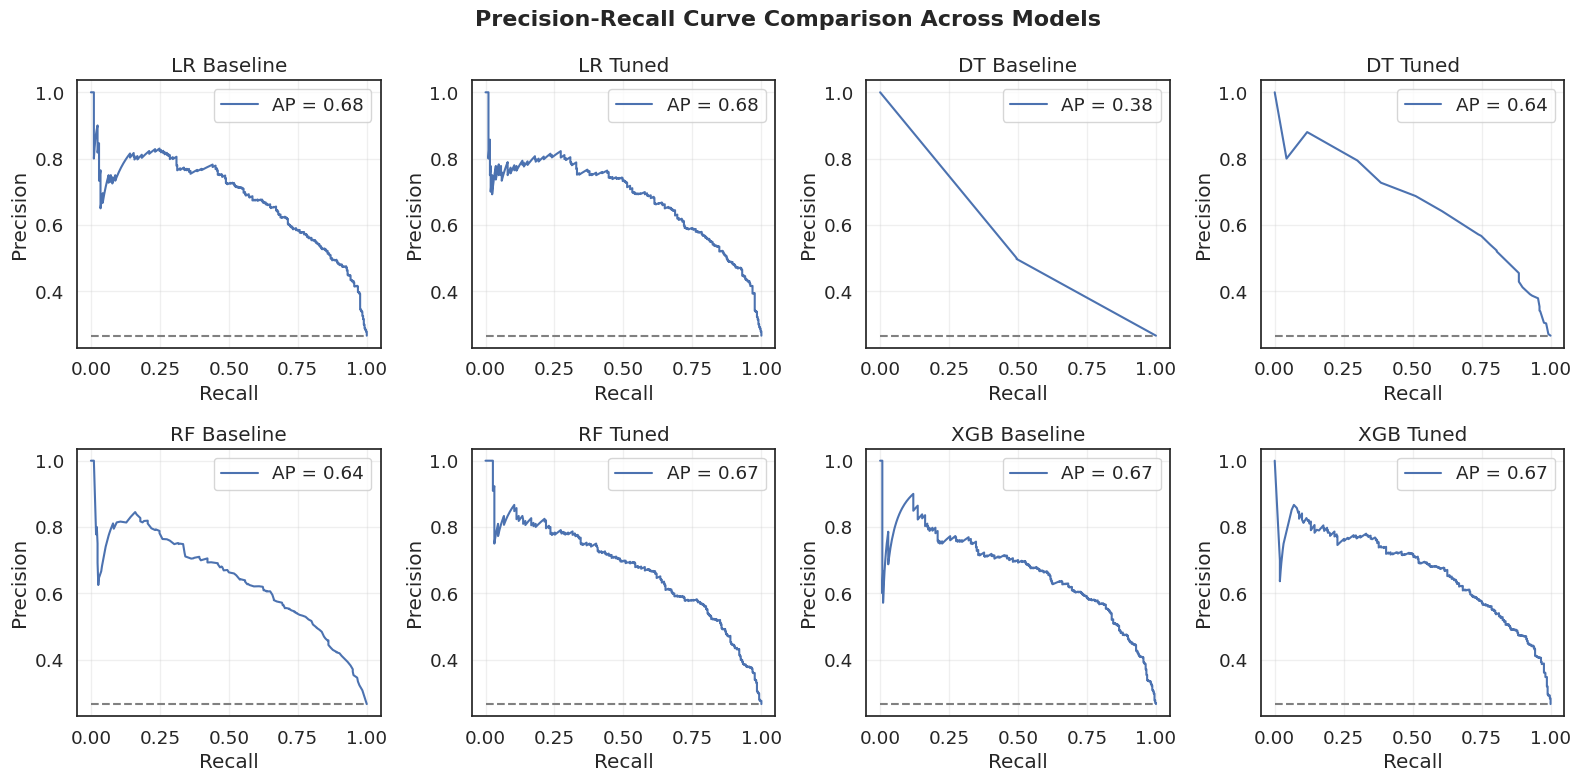

In [ ]:
# Store baseline and tuned models in a dictionary for comparison
models = {
    "LR Baseline": lr_pipe,
    "LR Tuned": lr_grid.best_estimator_,
    "DT Baseline": dt_pipe,
    "DT Tuned": dt_grid.best_estimator_,
    "RF Baseline": rf_pipe,
    "RF Tuned": rf_grid.best_estimator_,
    "XGB Baseline": xgb_pipe,
    "XGB Tuned": xgb_search.best_estimator_
}

# Create a 2x4 grid of subplots to display Precision-Recall curves for all models
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Compute the baseline precision (equivalent to the churn rate)
baseline = y_test.mean()

# Generate a Precision-Recall curve for each model
for ax, (name, model) in zip(axes, models.items()):

    # Obtain predicted probabilities for the positive class (churn)
    y_scores = model.predict_proba(X_test)[:, 1]

    # Compute precision and recall values across classification thresholds
    precision, recall, _ = precision_recall_curve(y_test, y_scores)

    # Calculate Average Precision (AP) as a summary metric
    ap_score = average_precision_score(y_test, y_scores)

    # Plot the Precision-Recall curve
    ax.plot(recall, precision, label=f"AP = {ap_score:.2f}")

    # Plot baseline precision representing a random classifier
    ax.hlines(
        y=baseline,
        xmin=0,
        xmax=1,
        linestyles="dashed",
        colors="gray"
    )

    # Configure subplot labels and formatting
    ax.set_title(name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(alpha=0.3)
    ax.legend()

# Add an overall title for the figure
fig.suptitle("Precision-Recall Curve Comparison Across Models", fontsize=16, weight="bold")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

### **Key Insights from the Precision-Recall Curve**

The Precision-Recall curves show that **Logistic Regression** achieves the highest Average Precision (**0.68**), with the **tuned XGBoost model** performing similarly (**0.67**). However, **XGBoost was selected as the final model** because the primary objective of this project is to **maximise recall** and identify as many churners as possible.

With the **highest recall (0.87)** among all models, the tuned XGBoost model captures the largest proportion of customers likely to churn. Although this results in more false positives, this trade-off is acceptable in churn prediction, where missing a true churner can lead to greater business loss than contacting a customer who may not churn.

---

# **Final Model Selection: Tuned XGBoost**

Several models were evaluated, including **Logistic Regression, Decision Tree, Random Forest, and XGBoost**. While multiple models achieved comparable overall accuracy and Average Precision, the primary objective of this project was to **maximise recall**, ensuring that customers likely to churn are correctly identified.

Among the evaluated models, the **tuned XGBoost model achieved the highest recall (0.87)** on the test set, substantially improving churn detection compared with the baseline XGBoost model (recall = 0.54) and the other tree-based models. Although **Logistic Regression achieved a slightly higher Average Precision (0.68)**, the **tuned XGBoost model performed similarly (0.67)** while identifying a larger proportion of churners.

XGBoost is a **gradient boosting algorithm** that builds an ensemble of decision trees sequentially, with each tree learning from the errors of the previous ones. This allows the model to capture **complex nonlinear relationships and feature interactions** within the customer data.

Hyperparameter tuning further improved performance by optimising parameters such as:

- **max_depth** - controlling tree complexity  
- **learning_rate** - regulating the contribution of each tree  
- **subsample and colsample parameters** - improving generalisation through sampling  
- **scale_pos_weight** - addressing class imbalance by increasing the penalty for misclassifying churners  

Compared with other models:

- **Logistic Regression** offered strong interpretability but is limited in capturing nonlinear relationships.
- **Decision Trees** improved after tuning but remained more prone to overfitting.
- **Random Forest** provided strong overall performance but achieved slightly lower recall than the tuned XGBoost model.

The confusion matrix confirms that the tuned XGBoost model successfully identifies the majority of churners while accepting a higher number of false positives. In churn prediction, this trade-off is often acceptable because **missing a true churner typically carries a greater business cost than contacting a customer who may not churn**.

> For these reasons, the **tuned XGBoost model was selected as the final model**, as it best aligns with the project objective of **maximising churn detection while maintaining strong overall predictive performance**.

**Note:** In real-world deployments, the final model would typically involve **optimising the classification threshold** to balance recall, precision, and operational costs. Organisations often adjust this threshold based on **retention campaign budgets, intervention costs, and expected customer lifetime value**.

# **Model Explainability (SHAP)**

SHAP (SHapley Additive exPlanations) was used to interpret the **tuned XGBoost model (best model)** by quantifying how each feature contributes to churn predictions.  

The summary plot highlights the **most influential features**, helping explain the model's behaviour and identify the key drivers of churn.

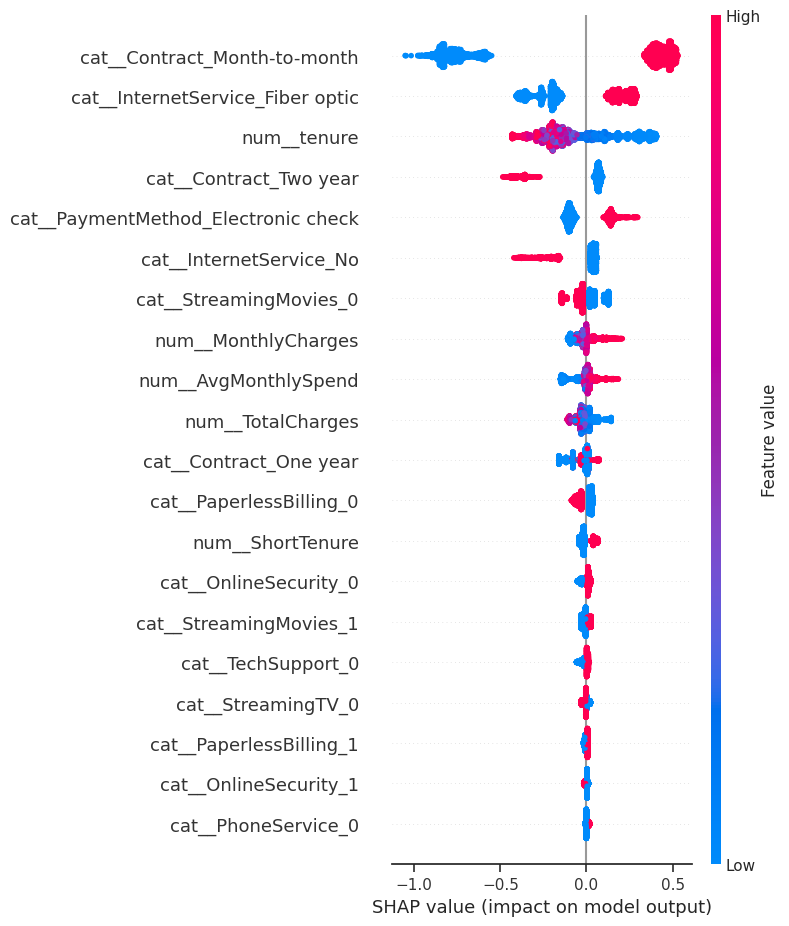

In [ ]:
# Select the best tuned pipeline from the search results
best_pipe = xgb_search.best_estimator_
# Extract the trained XGBoost model from the pipeline
model = best_pipe.named_steps["model"]
# Extract the preprocessing transformer from the pipeline
preprocessor = best_pipe.named_steps["preprocessing"]

# Apply preprocessing transformations to the training feature set
X_train_transformed = preprocessor.transform(X_train)

# Retrieve output feature names after preprocessing and encoding
feature_names = preprocessor.get_feature_names_out()

# Convert the transformed array into a dataframe for readable SHAP outputs
X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

# Initialize a SHAP explainer for the trained tree-based model
explainer = shap.TreeExplainer(model)
# Compute SHAP values for the transformed training data
shap_values = explainer.shap_values(X_train_transformed)

# Plot global feature importance using SHAP summary visualization
shap.summary_plot(shap_values, X_train_transformed)

### **Key Insights from the SHAP Summary Plot**

The SHAP summary plot highlights the features that most strongly influence the model's churn predictions and shows how different feature values increase or decrease churn risk. Several key patterns emerge from the analysis.

1. **Contract commitment is the strongest driver of churn**  
Customers on **month-to-month contracts** have a significantly higher probability of churn, while **one-year and two-year contracts strongly reduce churn risk**. This likely reflects the lower switching barriers associated with flexible contracts, as customers without long-term commitments can more easily leave if they encounter dissatisfaction, pricing concerns, or competitive offers.

2. **Internet service type impacts churn risk**  
Customers using **fiber optic internet** show a higher likelihood of churn compared with DSL users or customers without internet service. This may reflect **higher pricing or greater service expectations** associated with fiber plans, making customers more sensitive to perceived value and service quality.

3. **Customer tenure is a major retention indicator**  
**Tenure is one of the most influential predictors of churn.** Customers with shorter tenure show a much higher churn risk, while long-tenured customers demonstrate strong retention. This aligns with common customer lifecycle patterns, where early-stage customers are still evaluating the service and have not yet developed switching costs or loyalty.

4. **Payment behaviour signals churn risk**  
Customers paying via **electronic check** show higher churn probability compared with those using automated methods such as **credit card or bank transfer**. Automatic payments may reflect stronger customer commitment and reduce billing friction, both of which can contribute to higher retention.

5. **Pricing contributes to churn behaviour**  
Higher **MonthlyCharges** and **AvgMonthlySpend** increase churn probability. This suggests that **price sensitivity may play a role**, particularly when customers perceive the service value as insufficient relative to the monthly cost.

6. **Limited service adoption slightly increases churn risk**  
Customers without additional services such as **OnlineSecurity, TechSupport, or streaming services** show a modestly higher likelihood of churn. Greater service adoption may increase perceived value and create stronger integration with the provider's ecosystem.

> **Overall Insight:** The SHAP analysis identifies **contract type, tenure, internet service, payment behaviour, and pricing** as the primary drivers of churn. These insights suggest that retention strategies should prioritise **early-tenure customers, month-to-month subscribers, and customers facing higher monthly charges**, where churn risk appears to be highest.

# **Business Impact Analysis**

## **Quantifying Financial Impact from Recall Improvement**

This section translates the model's **recall uplift** into a projected business impact.

Based on the improvement in churn-class recall (baseline vs tuned XGBoost), the observed churn rate, and a simple forward-looking **LTV proxy**, the impact is estimated per **10,000 customers**:

- The number of **additional churners correctly identified**
- The estimated **future revenue at risk** associated with those churners
- The **recoverable revenue** under a conservative retention effectiveness assumption (e.g., **30%**)

This provides a practical bridge between model performance metrics and **scalable financial value**, supporting business-facing interpretation of the model improvement.

In [ ]:
# Define the assumed retention success rate after intervention
retention_success = 0.30
# Define the reporting scale for normalizing results
reporting_scale = 10_000

# Generate predictions from the baseline and tuned XGBoost models
y_pred_xgb_base = xgb_pipe.predict(X_test)
y_pred_xgb_tuned = xgb_search.predict(X_test)

# Compute recall for churners (positive class) before and after tuning
recall_old = recall_score(y_test, y_pred_xgb_base, pos_label=1)
recall_new = recall_score(y_test, y_pred_xgb_tuned, pos_label=1)
# Calculate the absolute improvement in recall
delta_recall = recall_new - recall_old

# Calculate churn rate in the test set
churn_rate = y_test.mean()

# Estimate additional churners identified per reporting scale due to recall improvement
extra_churners_per_scale = reporting_scale * churn_rate * delta_recall

# Compute average MonthlyCharges for churners
avg_monthly_churn = float(df.loc[df["Churn"] == 1, "MonthlyCharges"].mean())
# Compute average tenure for churners and non-churners
avg_tenure_churn = float(df.loc[df["Churn"] == 1, "tenure"].mean())
avg_tenure_nonchurn = float(df.loc[df["Churn"] == 0, "tenure"].mean())

# Estimate remaining customer lifetime in months using tenure difference
expected_remaining_months = max(0.0, avg_tenure_nonchurn - avg_tenure_churn)

# Approximate lifetime value per churner using monthly charges and remaining months proxy
ltv_proxy = avg_monthly_churn * expected_remaining_months

# Estimate revenue at risk based on additional churners identified
at_risk_per_scale = extra_churners_per_scale * ltv_proxy
# Estimate recoverable revenue using the assumed retention success rate
recoverable_per_scale = at_risk_per_scale * retention_success

# Print recall comparison and churn rate summary
print(f"Recall improvement: {recall_old:.2f} -> {recall_new:.2f}  (DELTA = {delta_recall:+.2f})")
print(f"Churn rate: {churn_rate:.3f}")

# Print estimated incremental churners identified per reporting scale
print(f"\nExtra churners identified per {reporting_scale:,}:")
print(f"{reporting_scale:,} x {churn_rate:.3f} x {delta_recall:.2f} = {extra_churners_per_scale:.0f}")

# Print churner revenue and tenure profile assumptions
print("\nChurner revenue profile:")
print(f"Average MonthlyCharges (churners): £{avg_monthly_churn:.2f}")
print(f"Average tenure (churners): {avg_tenure_churn:.2f} months")
print(f"Average tenure (non-churners): {avg_tenure_nonchurn:.2f} months")
print(f"Remaining months proxy: {avg_tenure_nonchurn:.2f} − {avg_tenure_churn:.2f} = {expected_remaining_months:.2f}")

# Print lifetime value proxy calculation
print(f"\nLTV proxy per churner:")
print(f"£{avg_monthly_churn:.2f} x {expected_remaining_months:.2f} = £{ltv_proxy:,.2f}")

# Print revenue at risk per reporting scale
print(f"\nAt-risk revenue per {reporting_scale:,}:")
print(f"{extra_churners_per_scale:.0f} x £{ltv_proxy:,.2f} = £{at_risk_per_scale:,.0f}")

# Print recoverable revenue estimate per reporting scale
print(f"\nRecoverable revenue per {reporting_scale:,} (Assuming 30% retention effectivenes):")
print(f"£{at_risk_per_scale:,.0f} x {retention_success:.0%} = £{recoverable_per_scale:,.0f}")

Recall improvement: 0.54 -> 0.87  (DELTA = +0.33)
Churn rate: 0.266

Extra churners identified per 10,000:
10,000 x 0.266 x 0.33 = 867

Churner revenue profile:
Average MonthlyCharges (churners): £74.44
Average tenure (churners): 17.98 months
Average tenure (non-churners): 37.65 months
Remaining months proxy: 37.65 − 17.98 = 19.67

LTV proxy per churner:
£74.44 x 19.67 = £1,464.33

At-risk revenue per 10,000:
867 x £1,464.33 = £1,269,707

Recoverable revenue per 10,000 (Assuming 30% retention effectivenes):
£1,269,707 x 30% = £380,912


## **Financial Impact Projection (Scaled to 10,000 Customers)**

### Model Performance Uplift
- Recall improved from **54% to 87%**
- Absolute recall increase: **+33 percentage points**
- Observed churn rate: **26.6%**

---

### Additional Churners Identified

Scaling the recall improvement to a cohort of **10,000 customers**:

10,000 x 0.266 x 0.33 ≈ **867**

The tuned model identifies **~867 additional churners per 10,000 customers** that would have been missed by the baseline model.

---

### Revenue Exposure per Churner

Churned customers generate on average:

- **£74.44 per month**
- Average tenure (churners): **17.98 months**
- Average tenure (non-churners): **37.65 months**

Estimated remaining revenue window lost due to churn:

37.65 - 17.98 = **19.67 months**

Estimated future revenue per churner:

£74.44 x 19.67 ≈ **£1,464**

This serves as a **forward-looking lifetime value (LTV) proxy**.

---

### Projected Financial Impact (Per 10,000 Customers)

- **Total future revenue exposure identified**

867 x £1,464 ≈ **£1.27M**

- **Recoverable revenue (assuming 30% retention success)**

£1.27M x 30% ≈ **£381k**

---

### Interpretation

By prioritising **recall**, the tuned model identifies substantially more customers at risk of churn. Under conservative retention assumptions, this corresponds to approximately **£381k in potentially recoverable lifetime value per 10,000 customers**.

This estimate illustrates how improvements in model performance can translate directly into **scalable financial impact**, while recognising that realised value depends on the effectiveness of retention strategies.

---

### **Assumptions and Limitations**

This financial estimate is intended as an illustrative projection rather than a precise revenue forecast. Several simplifying assumptions were made:

- The **30% retention success rate** represents a conservative assumption and may vary depending on the effectiveness of retention campaigns.
- The calculation assumes that **all detected churners receive retention intervention**, which may not always be operationally feasible.
- The **LTV proxy** is estimated using average monthly charges and tenure differences, rather than full customer lifetime modelling.
- The analysis does **not account for retention campaign costs**, which would reduce the net financial benefit.

Despite these simplifications, the estimate demonstrates how improvements in churn detection can translate into **meaningful potential business value at scale**.

# **Business Recommendations**

## **Actionable Insights for Reducing Churn**

### Financial Context
The tuned **XGBoost model** identifies approximately **867 additional at-risk customers per 10,000**, corresponding to roughly **£381k in potentially recoverable lifetime value** under conservative retention assumptions (30% retention effectiveness). The strategies below translate these predictive insights into practical retention actions.

---

### 1. Focus on High-Risk Customer Segments

SHAP analysis highlights the strongest churn drivers, enabling targeted intervention:

- **Month-to-month contracts**
- **Short tenure (new customers)**
- **Fiber optic internet service**
- **Higher monthly charges**
- **Electronic check payment method**
- **Lack of support or security services**

Prioritising these segments allows retention teams to allocate resources efficiently and intervene before customers disengage.

---

### 2. Deploy Targeted Retention Campaigns

Retention initiatives should prioritise **customers flagged as high-risk by the model**, using strategies such as:

- Targeted discounts or loyalty incentives  
- Bundled value-added services (e.g., tech support or security)  
- Early engagement with new customers on flexible contracts  

Personalised interventions can strengthen engagement and encourage longer-term customer relationships.

---

### 3. Address Service and Pricing Drivers

Key churn drivers suggest opportunities to improve the customer experience:

- **Fiber optic users** may require service quality improvements or better support  
- **Higher monthly charges** indicate potential pricing sensitivity  
- **Electronic check users** may benefit from incentives to adopt automatic payments

Addressing these factors can help reduce churn risk at the source.

---

### 4. Continuously Monitor and Improve

Retention strategies should be evaluated using measurable outcomes:

- **Churn rate trends**
- **Retention campaign ROI**
- **Customer satisfaction and feedback**

Predictive models should also be **periodically retrained with new data** to ensure continued accuracy as customer behaviour evolves.

---

## Conclusion

By combining **predictive modeling, explainability (SHAP), and targeted retention strategies**, organisations can proactively identify high-risk customers, optimise intervention efforts, and protect long-term customer value.

# **Deployment**

The trained model artifacts were saved, and the application was developed using Visual Studio. The project was version-controlled with GitHub and **deployed** as a web application using Streamlit.

**Link:** https://mg-churn.streamlit.app/

In [ ]:
# Save the best tuned pipeline (includes preprocessing and trained XGBoost model)
# This allows raw input data to be passed directly to the pipeline during prediction
best_pipe = xgb_search.best_estimator_
joblib.dump(best_pipe, "churn_xgb_pipeline.pkl")

# Save the training median used to create the HighMonthlyCharges feature
# Required to recreate the same feature engineering step during deployment
median_charge = X_train["MonthlyCharges"].median()
joblib.dump(median_charge, "monthlycharges_median.pkl")

# Save the expected input feature columns
# Helps validate incoming data and maintain consistent feature ordering in deployment
joblib.dump(X_train.columns.tolist(), "raw_input_columns.pkl")

['raw_input_columns.pkl']

In [ ]:
import sklearn
import xgboost
import sys

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
scikit-learn: 1.6.1
xgboost: 3.2.0


# **Limitations**

While the model demonstrates strong predictive performance, several limitations should be acknowledged.

> **Dataset Scope:** The analysis relies on a relatively small dataset (~7,000 customers) with limited behavioural information. Additional features such as customer usage patterns, service quality metrics, or interaction history could further improve predictive performance.

> **Simplified Financial Estimation:** The financial impact projection is based on simplified assumptions, including an estimated retention success rate and a proxy for future customer value. In practice, a more detailed customer lifetime value model and retention cost analysis would be required.

> **Static Snapshot of Customer Behaviour:** The dataset represents a static view of customer attributes rather than a time-series record of behaviour. Incorporating temporal customer activity could improve churn prediction.

> **Threshold Selection:** The model uses the default classification threshold (0.5). In real-world deployments, this threshold would typically be optimised to balance recall, precision, and operational costs.

# **Future Work**

> **Enhanced Feature Engineering:** Develop **interaction or behavioural features** to better capture complex customer usage patterns and improve predictive performance.

> **Deeper Model Explainability:** Extend SHAP analysis to **customer-level explanations**, enabling targeted retention actions for individual at-risk customers.

> **Advanced Imbalance Handling:** Explore alternative imbalance-handling techniques, such as SMOTE or other resampling methods, to evaluate whether further improvements in churn detection can be achieved. While class weighting was appropriate given the moderate imbalance, these approaches could be investigated to assess their potential impact on recall-focused performance.

> **Deployment Improvements:** Extend the current deployment toward **real-time prediction and model monitoring**, allowing businesses to detect churn risk earlier and track model performance over time.

# **Conclusion**

This project demonstrates how machine learning can be leveraged to support **proactive customer retention strategies in subscription-based businesses**. Through exploratory analysis and predictive modelling, key patterns associated with churn were identified across **customer demographics, service adoption, and billing behaviour**.

Multiple models were developed and evaluated, with optimisation focused on **recall**, ensuring that as many potential churners as possible are identified. The final tuned model provides a practical framework for **early churn risk detection**, enabling businesses to intervene before customers leave.

By combining **predictive modelling, model explainability, and business impact estimation**, this project illustrates how data-driven insights can translate into **actionable retention strategies and measurable business value**. Such approaches allow organisations to **prioritise high-risk customers, optimise retention efforts, and reduce revenue loss due to churn**.